# Ontario Highway Network Analysis

This notebook walks through the key analysis steps to identify potential corridors or hubs of interest for shared charging on Ontario's road network based on survey data.

Looking for an Overlap between the following attributes:

- Locations where we expect trucks to have Low SOC \(min SOC\) &  \-\-\> routes that we are going to receive are majorly based on diesel

- Amount of traffic \(volume of freight flow\)

- Frequency Dwell Times

- Where is there expected to be public support for EV class 7\-8 charging hubs? Forecast of where any future hubs will be built

- Commercial Electricity Rates \(Alectra utilities & Toronto Hydro rates\)

General considerations

- Need to consider that we are making a corridor, not a hub

- Existing infrastructure that we can interconnect to: enough space for truck entry and parking

Project level considerations:

- Capacity upgrades\.\.\. regional power generation capacity to supply this load\. Might save time in project development

Output: 3\-4 ideal locations in the GTHA \(a km range circle\)


Postal code inputs to add from survey

General FSA, rest stops, and preferences of hubs

## 0. Install Required Packages

If you haven't already, install the required packages using pip:

In [108]:
import subprocess
import sys

# Install required packages
packages = [
    'geopandas',
    'pandas',
    'numpy',
    'matplotlib',
    'shapely'
]

print("Installing required packages...")
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    print(f"✓ {package} installed")

print("\n✓ All required packages installed successfully")

Installing required packages...
✓ geopandas installed
✓ pandas installed
✓ numpy installed
✓ matplotlib installed
✓ shapely installed

✓ All required packages installed successfully


## 0.5 Download Data Files

Download required GeoJSON files if they don't already exist in the data directory.

In [109]:
import os
import subprocess

# Create data directory if it doesn't exist
data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)

# Define files to download
files_to_download = {
    'Ontario_Provincial_Boundary.geojson': 'https://hub.arcgis.com/api/v3/datasets/337b896c7862411ba365159b4cd9c8c7_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1',
    'Value_of_Goods_2016_-3795296180828259022.geojson': 'https://stg-arcgisazurecdataprod.az.arcgis.com/exportfiles-4893-6785/Value_of_Goods_2016_-3795296180828259022.geojson?sv=2025-05-05&st=2026-01-14T01%3A47%3A18Z&se=2026-01-14T02%3A52%3A18Z&sr=c&sp=r&sig=Euk7L0NNLSS019VXoLRRlVk%2BTQoPTJJ%2Bc%2FFW3EvOAw4%3D'
}

print("Checking data files...")
for filename, url in files_to_download.items():
    filepath = os.path.join(data_dir, filename)
    
    if os.path.exists(filepath):
        file_size = os.path.getsize(filepath)
        print(f"✓ {filename} exists ({file_size:,} bytes)")
    else:
        print(f"⬇ Downloading {filename}...")
        try:
            subprocess.run(['curl', '-L', '-o', filepath, url], check=True, capture_output=True)
            file_size = os.path.getsize(filepath)
            print(f"  ✓ Downloaded {filename} ({file_size:,} bytes)")
        except subprocess.CalledProcessError as e:
            print(f"  ✗ Error downloading {filename}: {e}")
        except FileNotFoundError:
            print(f"  ✗ curl not found. Please install curl or download files manually.")

print("\n✓ Data file check complete")

Checking data files...
✓ Ontario_Provincial_Boundary.geojson exists (1,000,426 bytes)
✓ Value_of_Goods_2016_-3795296180828259022.geojson exists (15,366,648 bytes)

✓ Data file check complete


## 1. Import Libraries and Custom Modules

In [110]:
# Standard libraries
import sys
import json
import importlib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# Add source directory to path for custom modules
sys.path.insert(0, '../source')

# Import and reload to pick up any code changes
import map_generation
importlib.reload(map_generation)

from map_generation import (
    load_data,
    load_ontario_boundary,
    geojson_to_gdf,
    normalize_highway_name,
    get_highway_color,
    get_distinct_colors,
    create_pdf_map,
    create_weighted_pdf_map
)

print("✓ All libraries imported successfully (module reloaded)")

✓ All libraries imported successfully (module reloaded)


## 2. Load and Prepare Data

We'll load three main data sources:
1. **GeoJSON**: Road network with 13,981 segments across Ontario
2. **Target Highways CSV**: 14 highways identified in fleet survey
3. **Provincial Boundary**: Ontario boundary for context

In [111]:
# Define data paths
GEOJSON_PATH = "../data/Value_of_Goods_2016_-3795296180828259022.geojson"
HIGHWAYS_CSV_PATH = "../data/target_highways.csv"
ONTARIO_BOUNDARY_PATH = "../data/Ontario_Provincial_Boundary.geojson"

# Load all data using utility functions
print("Loading data...")
geojson_data, highways_df = load_data(GEOJSON_PATH, HIGHWAYS_CSV_PATH)
gdf_ontario = load_ontario_boundary(ONTARIO_BOUNDARY_PATH)

print(f"✓ GeoJSON loaded: {len(geojson_data['features'])} features")
print(f"✓ Target highways loaded: {len(highways_df)} highways")
print(f"✓ Ontario boundary loaded")

# Convert to GeoDataFrames
print("\nConverting to GeoDataFrames...")
gdf_all = geojson_to_gdf(geojson_data)
gdf_targets = geojson_to_gdf(geojson_data, highways_df, filter_targets=True)

# Summary
print(f"✓ All road segments: {len(gdf_all)}")
print(f"✓ Target highway segments: {len(gdf_targets)}")
print(f"✓ Target highways included: {sorted(gdf_targets['matched_highway'].unique())}")
print("\nTarget segment counts (by matched_highway):")
print(gdf_targets['matched_highway'].value_counts().sort_index())

Loading data...
✓ GeoJSON loaded: 13981 features
✓ Target highways loaded: 15 highways
✓ Ontario boundary loaded

Converting to GeoDataFrames...
✓ All road segments: 13981
✓ Target highway segments: 5245
✓ Target highways included: ['11', '17', '400', '401', '402', '403', '410', '416', '417', '427', '69', '7', '8', '85', 'QEW']

Target segment counts (by matched_highway):
matched_highway
11      885
17      474
400     232
401    1014
402      82
403     202
410      54
416      57
417     244
427      98
69       79
7      1200
8       392
85       38
QEW     194
Name: count, dtype: int64


## 3. Initial Data Exploration

In [112]:
# Display target highways table
print("=" * 60)
print("TARGET HIGHWAYS FROM SURVEY")
print("=" * 60)
print(highways_df.to_string(index=False))
print()

# Analyze survey mention frequency
count_distribution = highways_df['count'].value_counts().sort_index(ascending=False)
print("\nSurvey Mention Frequency Distribution:")
for count in sorted(count_distribution.index, reverse=True):
    color_name = {1: 'Red', 2: 'Orange', 3: 'Green'}.get(count, 'Other')
    num_highways = count_distribution[count]
    print(f"  Count {count} ({color_name}): {num_highways} highway(s)")

TARGET HIGHWAYS FROM SURVEY
highway  count
      7      1
      8      1
     11      1
     17      1
     69      1
     85      1
    400      2
    401      3
    402      1
    403      2
    410      1
    416      1
    417      1
    427      1
    QEW      2


Survey Mention Frequency Distribution:
  Count 3 (Green): 1 highway(s)
  Count 2 (Orange): 3 highway(s)
  Count 1 (Red): 11 highway(s)


In [113]:
# Analyze road network attributes
print("\n" + "=" * 60)
print("ROAD NETWORK STATISTICS")
print("=" * 60)

print(f"\nBase Network (all roads):")
print(f"  Total segments: {len(gdf_all):,}")
print(f"  CRS: {gdf_all.crs}")

print(f"\nTarget Network (filtered highways):")
print(f"  Total segments: {len(gdf_targets):,}")
print(f"  Unique highways: {gdf_targets['matched_highway'].nunique()}")

# Check available attributes for weighting
weight_columns = ['AADTT16', 'VOG_WGT', 'VOG16']
print(f"\nAvailable weight attributes:")
for col in weight_columns:
    if col in gdf_targets.columns:
        valid_count = gdf_targets[col].notna().sum()
        if valid_count > 0:
            print(f"  {col}: {valid_count:,} segments with data")
            print(f"    - Min: {gdf_targets[col].min():.2f}")
            print(f"    - Max: {gdf_targets[col].max():.2f}")
            print(f"    - Mean: {gdf_targets[col].mean():.2f}")
        else:
            print(f"  {col}: No data available")


ROAD NETWORK STATISTICS

Base Network (all roads):
  Total segments: 13,981
  CRS: None

Target Network (filtered highways):
  Total segments: 5,245
  Unique highways: 15

Available weight attributes:
  AADTT16: 5,245 segments with data
    - Min: 0.00
    - Max: 22223.00
    - Mean: 2906.38
  VOG_WGT: 5,245 segments with data
    - Min: 0.00
    - Max: 102038549.00
    - Mean: 16984585.56
  VOG16: 5,245 segments with data
    - Min: 0.00
    - Max: 360153000.00
    - Mean: 62715706.01


## 4. Map Generation - Basic Network View

Generate a map with target highways colored by survey mention frequency:
- **Red**: Mentioned 1 time
- **Orange**: Mentioned 2 times  
- **Green**: Mentioned 3 times

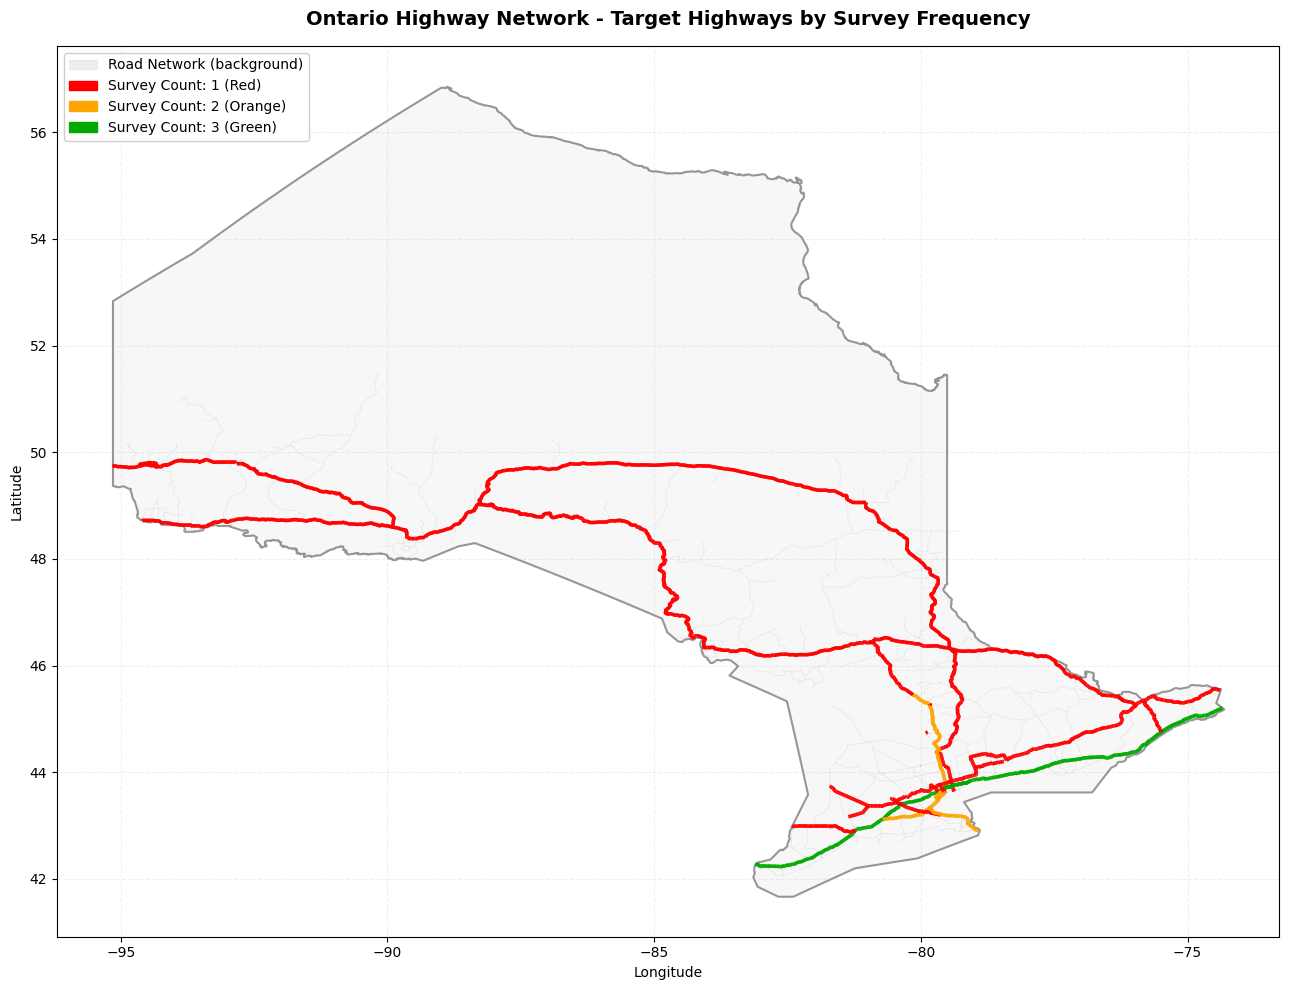

✓ Basic map visualization displayed


In [114]:
# Create a simplified map visualization in the notebook
fig, ax = plt.subplots(figsize=(14, 10))

# Set background color
ax.set_facecolor('white')

# Add Ontario boundary
gdf_ontario.plot(ax=ax, color='#F0F0F0', edgecolor='#333333', linewidth=1.5, alpha=0.5, zorder=0)

# Plot base network (all roads in light black)
gdf_all.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.3, zorder=1)

# Create color mapping for target highways
highway_info = highways_df.copy()
highway_info['highway'] = highway_info['highway'].astype(str)
highway_info = highway_info.set_index('highway').to_dict('index')

# Collect and plot colored segments
line_segments = []
line_colors = []

for hwy in sorted(gdf_targets['matched_highway'].unique()):
    if hwy in highway_info:
        count = highway_info[hwy]['count']
        color = get_highway_color(count)
        
        hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
        
        for idx, row in hwy_gdf.iterrows():
            geom = row.geometry
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                line_segments.append(coords)
                line_colors.append(color)

# Add colored line collection
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=2.5, alpha=0.85, zorder=3)
    ax.add_collection(lc)
    ax.autoscale()

# Create legend
legend_elements = [
    mpatches.Patch(color='#CCCCCC', alpha=0.3, label='Road Network (background)'),
    mpatches.Patch(color='#FF0000', label='Survey Count: 1 (Red)'),
    mpatches.Patch(color='#FFA500', label='Survey Count: 2 (Orange)'),
    mpatches.Patch(color='#00AA00', label='Survey Count: 3 (Green)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

ax.set_title('Ontario Highway Network - Target Highways by Survey Frequency', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

print("✓ Basic map visualization displayed")

## 5. Map Generation - Individual Highway Visualization

Create a map with each highway in a distinct color and labeled for easy identification.

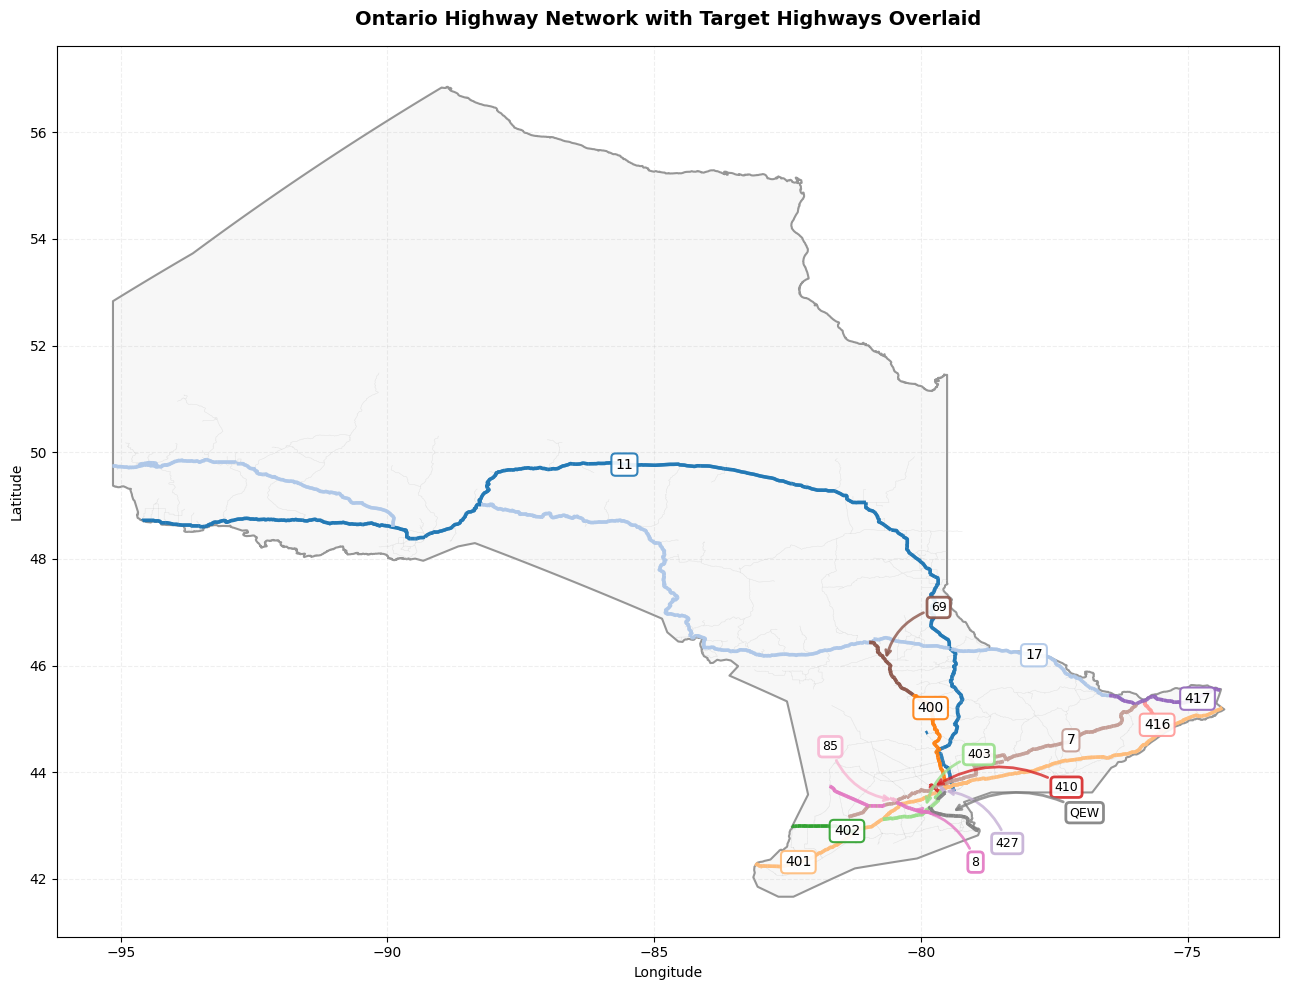

✓ Individual highway map displayed with smart labels
  - 15 unique highways visualized
  - 5245 total road segments
  - 7 highways with arrow labels
  - 8 highways with direct labels


In [115]:
# Create map with individual highway colors and smart label placement
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Add Ontario boundary
gdf_ontario.plot(ax=ax, color='#F0F0F0', edgecolor='#333333', linewidth=1.5, alpha=0.5, zorder=0)

# Plot base network
gdf_all.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.3, zorder=1)

# Get distinct colors for each highway
highways_list = sorted(gdf_targets['matched_highway'].unique())
colors_palette = get_distinct_colors(len(highways_list))
highway_color_map = {hwy: colors_palette[i] for i, hwy in enumerate(highways_list)}

# Custom label placement overrides for specific highways
label_overrides = {
    '69': {'mode': 'direct', 'description': 'Place directly over highway'},
    '8': {'mode': 'arrow', 'direction': 'lower_right', 'description': 'Place at far northwest corner'},
    '85': {'mode': 'arrow', 'direction': 'upper_left', 'description': 'Arrow to upper left'},
    '403': {'mode': 'arrow', 'direction': 'default', 'description': 'Arrow with default placement'},
    '410': {'mode': 'arrow', 'direction': 'far_right', 'description': 'Arrow to the right'},
    '427': {'mode': 'arrow', 'direction': 'lower_right', 'description': 'Arrow to lower right'},
    'QEW': {'mode': 'arrow', 'direction': 'far_right', 'description': 'Arrow to far right'},
}

# Collect segments and calculate label positions
line_segments = []
line_colors = []
highway_labels = {}
highway_bounds = {}

for hwy in highways_list:
    color = highway_color_map[hwy]
    hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
    
    all_coords = []
    all_segments = []
    longest_segment = None
    longest_length = 0
    
    for idx, row in hwy_gdf.iterrows():
        geom = row.geometry
        if geom.geom_type == 'LineString':
            coords = list(geom.coords)
            line_segments.append(coords)
            line_colors.append(color)
            all_coords.extend(coords)
            all_segments.append(coords)
            
            # Track longest segment for label placement
            segment_length = geom.length
            if segment_length > longest_length:
                longest_length = segment_length
                longest_segment = coords
    
    # Store bounds for this highway
    if all_coords:
        all_coords_array = np.array(all_coords)
        highway_bounds[hwy] = {
            'coords': all_coords_array,
            'longest_segment': longest_segment,
            'all_segments': all_segments
        }

# Calculate label positions based on overrides or smart placement
for hwy in highways_list:
    color = highway_color_map[hwy]
    bounds = highway_bounds[hwy]
    all_coords = bounds['coords']
    longest_segment = bounds['longest_segment']
    
    if hwy in label_overrides:
        override = label_overrides[hwy]
        mode = override['mode']
        
        if mode == 'direct':
            # Place label directly on highway (use longest segment midpoint)
            if longest_segment:
                segment_array = np.array(longest_segment)
                midpoint_idx = len(segment_array) // 2
                label_pos = tuple(segment_array[midpoint_idx])
            else:
                label_pos = tuple(all_coords.mean(axis=0))
            highway_labels[hwy] = {'pos': label_pos, 'mode': 'direct', 'color': color}
            
        elif mode == 'northwest_corner':
            # Find furthest west point (minimum longitude)
            label_pos = tuple(all_coords[np.argmin(all_coords[:, 0])])
            highway_labels[hwy] = {'pos': label_pos, 'mode': 'direct', 'color': color}
            
        elif mode == 'arrow':
            # Calculate center for arrow placement
            center = all_coords.mean(axis=0)
            direction = override.get('direction', 'default')
            
            # Calculate offset position based on direction
            if direction == 'upper_left':
                label_pos = (center[0] - 1.2, center[1] + 1.0)
            elif direction == 'far_northwest':
                label_pos = (center[0] - 2.2, center[1] + 1.5)
            elif direction == 'far_left':
                label_pos = (center[0] - 2.5, center[1])
            elif direction == 'far_right':
                label_pos = (center[0] + 2.5, center[1])
            elif direction == 'right':
                label_pos = (center[0] + 1.8, center[1])
            elif direction == 'lower_right':
                label_pos = (center[0] + 1.2, center[1] - 1.0)
            else:  # default
                label_pos = (center[0] + 1.0, center[1] + 1.0)
            
            highway_labels[hwy] = {
                'pos': label_pos,
                'mode': 'arrow',
                'arrow_to': tuple(center),
                'color': color
            }
    else:
        # Smart default placement using longest segment midpoint
        if longest_segment:
            segment_array = np.array(longest_segment)
            midpoint_idx = len(segment_array) // 2
            label_pos = tuple(segment_array[midpoint_idx])
        else:
            label_pos = tuple(all_coords.mean(axis=0))
        
        highway_labels[hwy] = {'pos': label_pos, 'mode': 'direct', 'color': color}

# Check for overlaps and convert to arrows if needed
overlap_threshold = 0.6
placed_positions = []

for hwy in highways_list:
    if highway_labels[hwy]['mode'] == 'direct':
        label_pos = highway_labels[hwy]['pos']
        
        # Check if this position overlaps with any already placed labels
        overlaps = False
        for placed_pos in placed_positions:
            distance = np.sqrt((label_pos[0] - placed_pos[0])**2 + (label_pos[1] - placed_pos[1])**2)
            if distance < overlap_threshold:
                overlaps = True
                break
        
        if overlaps:
            # Convert to arrow placement
            bounds = highway_bounds[hwy]
            center = bounds['coords'].mean(axis=0)
            
            # Find a good offset direction
            offset_pos = (center[0] + 1.0, center[1] + 1.0)
            highway_labels[hwy] = {
                'pos': offset_pos,
                'mode': 'arrow',
                'arrow_to': tuple(center),
                'color': highway_labels[hwy]['color']
            }
            placed_positions.append(offset_pos)
        else:
            placed_positions.append(label_pos)
    else:
        placed_positions.append(highway_labels[hwy]['pos'])

# Add colored line collection
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=2.5, alpha=0.85, zorder=3)
    ax.add_collection(lc)
    ax.autoscale()

# Add labels with arrows where appropriate
for hwy, label_info in highway_labels.items():
    color = label_info['color']
    pos = label_info['pos']
    
    if label_info['mode'] == 'arrow':
        # Add arrow pointing to highway
        arrow_to = label_info['arrow_to']
        ax.annotate(
            f'{hwy}',
            xy=arrow_to,
            xytext=pos,
            fontsize=9,
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=2, alpha=0.9),
            arrowprops=dict(
                arrowstyle='->',
                connectionstyle='arc3,rad=0.3',
                color=color,
                linewidth=2,
                alpha=0.8
            ),
            zorder=5
        )
    else:
        # Direct label placement
        ax.text(pos[0], pos[1], f'{hwy}', 
                fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, linewidth=1.5, alpha=0.9),
                zorder=5)

ax.set_title('Ontario Highway Network with Target Highways Overlaid', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

print("✓ Individual highway map displayed with smart labels")
print(f"  - {len(highways_list)} unique highways visualized")
print(f"  - {len(line_segments)} total road segments")
print(f"  - {sum(1 for l in highway_labels.values() if l['mode'] == 'arrow')} highways with arrow labels")
print(f"  - {sum(1 for l in highway_labels.values() if l['mode'] == 'direct')} highways with direct labels")

## 6. Weighted Visualizations

Create maps with line width weighted by traffic and goods attributes:
- **AADTT16**: Annual Average Daily Truck Traffic (2016)
- **VOG_WGT**: Value of Goods Weight
- **VOG16**: Value of Goods (2016)

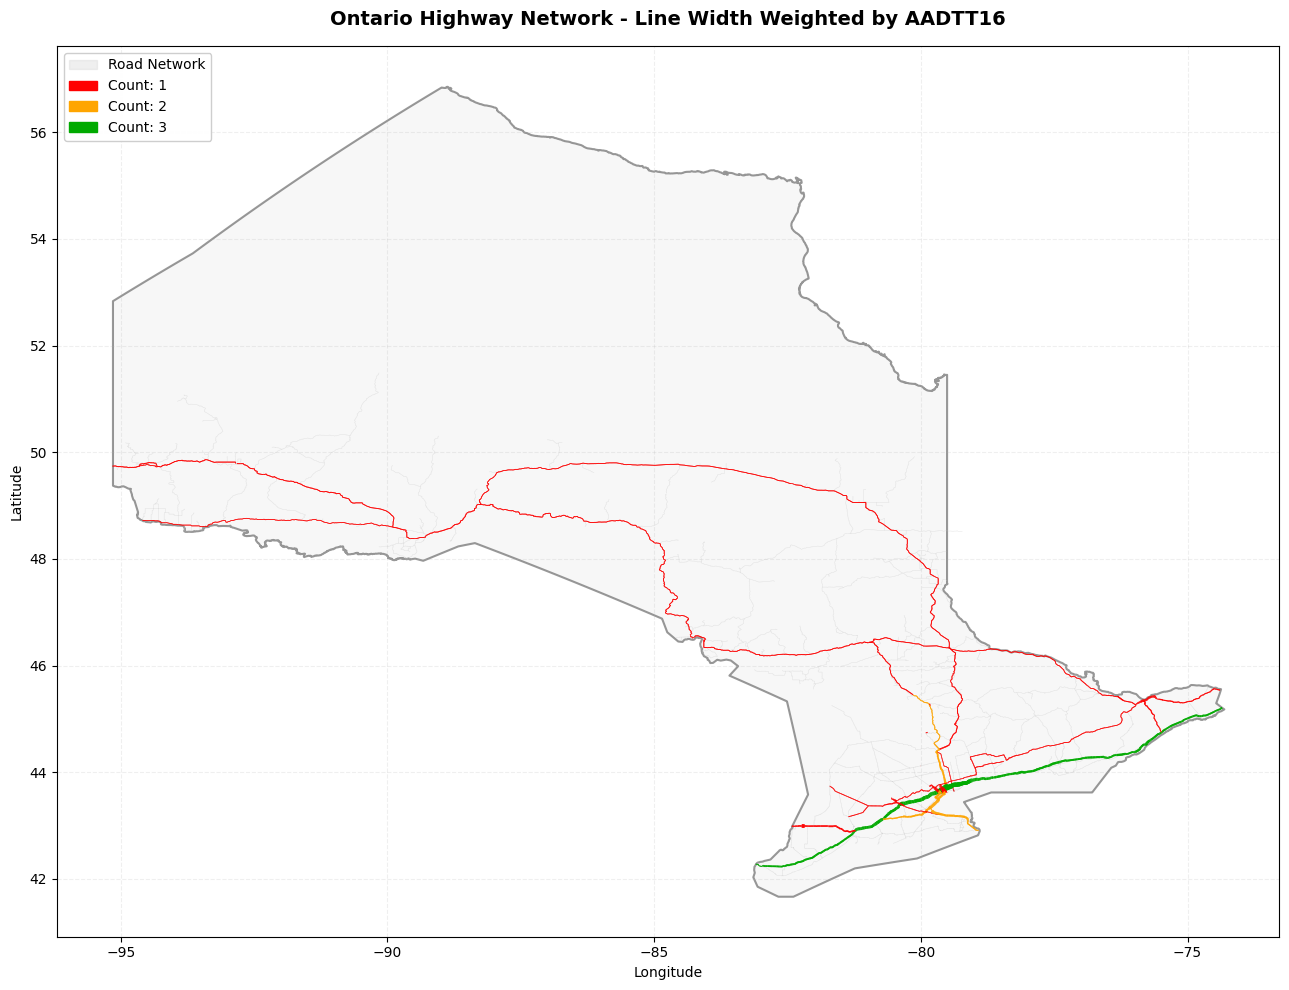

✓ Weighted map (AADTT16) displayed
  - Line width range: 0.50 to 4.50
  - AADTT16 range: 0 to 22223


In [116]:
# Create a weighted visualization example (AADTT16)
weight_by = 'AADTT16'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('white')

# Add Ontario boundary
gdf_ontario.plot(ax=ax, color='#F0F0F0', edgecolor='#333333', linewidth=1.5, alpha=0.5, zorder=0)

# Plot base network
gdf_all.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.3, zorder=1)

# Get min/max for weight normalization
valid_values = gdf_targets[weight_by].dropna()
if len(valid_values) > 0:
    min_val = valid_values.min()
    max_val = valid_values.max()
    if max_val == min_val:
        min_val = max_val - 1
else:
    min_val = 1
    max_val = 1

# Create colored segments with varying widths
line_segments = []
line_colors = []
line_widths = []

for hwy in sorted(gdf_targets['matched_highway'].unique()):
    if hwy in highway_info:
        count = highway_info[hwy]['count']
        color = get_highway_color(count)
        
        hwy_gdf = gdf_targets[gdf_targets['matched_highway'] == hwy]
        
        for idx, row in hwy_gdf.iterrows():
            # Calculate width based on attribute value
            if pd.notna(row[weight_by]) and max_val > min_val:
                normalized = (row[weight_by] - min_val) / (max_val - min_val)
                linewidth = 0.5 + normalized * 4  # Width from 0.5 to 4.5
            else:
                linewidth = 2.5
            
            geom = row.geometry
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                line_segments.append(coords)
                line_colors.append(color)
                line_widths.append(linewidth)

# Add line collection with varying widths
if line_segments:
    lc = LineCollection(line_segments, colors=line_colors, linewidths=line_widths, alpha=0.85, zorder=3)
    ax.add_collection(lc)
    ax.autoscale()

# Create legend
legend_elements = [
    mpatches.Patch(color='#CCCCCC', alpha=0.3, label='Road Network'),
    mpatches.Patch(color='#FF0000', label='Count: 1'),
    mpatches.Patch(color='#FFA500', label='Count: 2'),
    mpatches.Patch(color='#00AA00', label='Count: 3')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95)

ax.set_title(f'Ontario Highway Network - Line Width Weighted by {weight_by}', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

print(f"✓ Weighted map ({weight_by}) displayed")
print(f"  - Line width range: {min(line_widths):.2f} to {max(line_widths):.2f}")
print(f"  - {weight_by} range: {min_val:.0f} to {max_val:.0f}")

## 7. Export Maps

Use the map generation functions to export high-resolution PDF and PNG files for all visualizations.

In [117]:
# Export all map variants as high-resolution PDF and PNG files (300 DPI)
output_dir = '../plots'

print("Exporting maps...")
print()

# Map 1: Basic map with colors by count
print("1/3: Exporting basic map...")
fig, ax = create_pdf_map(gdf_all, gdf_targets, gdf_ontario, highways_df, 
                         'highway_network_map.pdf', output_dir)
plt.close(fig)

# Map 2: Weighted by AADTT16
print("2/3: Exporting AADTT16 weighted map...")
fig, ax = create_weighted_pdf_map(gdf_all, gdf_targets, gdf_ontario, highways_df, 
                                   'AADTT16', 'highway_network_map_aadtt16.pdf', output_dir)
plt.close(fig)

# Map 3: Weighted by VOG16
print("3/3: Exporting VOG16 weighted map...")
fig, ax = create_weighted_pdf_map(gdf_all, gdf_targets, gdf_ontario, highways_df, 
                                   'VOG16', 'highway_network_map_vog16.pdf', output_dir)
plt.close(fig)

print()
print("✓ All maps exported successfully!")
print(f"  Location: {output_dir}/")
print("  Format: PDF and PNG (300 DPI)")

Exporting maps...

1/3: Exporting basic map...
2/3: Exporting AADTT16 weighted map...
3/3: Exporting VOG16 weighted map...

✓ All maps exported successfully!
  Location: ../plots/
  Format: PDF and PNG (300 DPI)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f2eba73f-2262-40cf-8fa2-7979a0070886' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>

# Postal Code and Forward Sortation Area Analysis

Visualize survey postal codes as Forward Sortation Areas (FSAs) on a map of Ontario with customizable label placement.

In [118]:
# Import FSA analysis module
import importlib
sys.path.insert(0, '../source')
import postal_code_analysis
importlib.reload(postal_code_analysis)

from postal_code_analysis import (
    load_fsa_shapefile,
    load_postal_codes,
    load_ontario_boundary,
    filter_fsa_by_postal_codes,
    visualize_fsas
)

# Load postal codes
postal_codes_path = os.path.join(data_dir, 'postal_codes.csv')
df_postal = load_postal_codes(postal_codes_path)

print(f"Unique FSAs: {sorted(df_postal['FSA'].unique())}")

Loaded 24 records from postal codes CSV
Columns: ['Postal Code', 'Count']
Extracted 23 unique FSAs
FSAs: ['K0A', 'K0C', 'K0H', 'K0K', 'K6J', 'K6V', 'K7A', 'K7G', 'K8A', 'K9J', 'L0J', 'L3C', 'L4M', 'L4N', 'L5T', 'L6T', 'L6Y', 'L7E', 'M8V', 'N5A', 'N5C', 'N5W', 'P3E']
Unique FSAs: ['K0A', 'K0C', 'K0H', 'K0K', 'K6J', 'K6V', 'K7A', 'K7G', 'K8A', 'K9J', 'L0J', 'L3C', 'L4M', 'L4N', 'L5T', 'L6T', 'L6Y', 'L7E', 'M8V', 'N5A', 'N5C', 'N5W', 'P3E']


In [119]:
# Load FSA shapefile and filter to target postal codes
fsa_shapefile = os.path.join(data_dir, 'lfsa000b21a_e', 'lfsa000b21a_e.shp')
ontario_boundary_path = os.path.join(data_dir, 'Ontario_Provincial_Boundary.geojson')

# Load data using imported functions
gdf_fsa_all = load_fsa_shapefile(fsa_shapefile)
gdf_boundary_fsa = load_ontario_boundary(ontario_boundary_path)
gdf_fsa_target = filter_fsa_by_postal_codes(gdf_fsa_all, df_postal, gdf_boundary_fsa)

print(f"Loaded {len(gdf_fsa_all)} Ontario FSA records")
print(f"Filtered to {len(gdf_fsa_target)} FSA features matching target postal codes")

Loaded shapefile with 1643 total FSA records
Filtered to 520 Ontario FSA records
Loaded Ontario boundary

Coordinate Systems:
  FSA shapefile CRS: EPSG:3347
  Ontario boundary CRS: EPSG:4326
  → Reprojecting FSA shapefile to EPSG:4326
Filtered to 23 FSA features matching target postal codes
Loaded 520 Ontario FSA records
Filtered to 23 FSA features matching target postal codes


In [120]:
# Configure label directions for small FSAs
# Options: 'up', 'down', 'left', 'right', 'upper left', 'upper right', 'lower left', 'lower right'
label_directions = {
    'L4N': 'left',
    'K7G': 'right',
    'K6V': 'lower right',
    'K7A': 'down',
    'K6J': 'down',
    'L6Y': 'lower left',
    'L5T': 'down',
    'L6T': 'left'
}

Visualization saved to ../plots/fsa_visualization.png


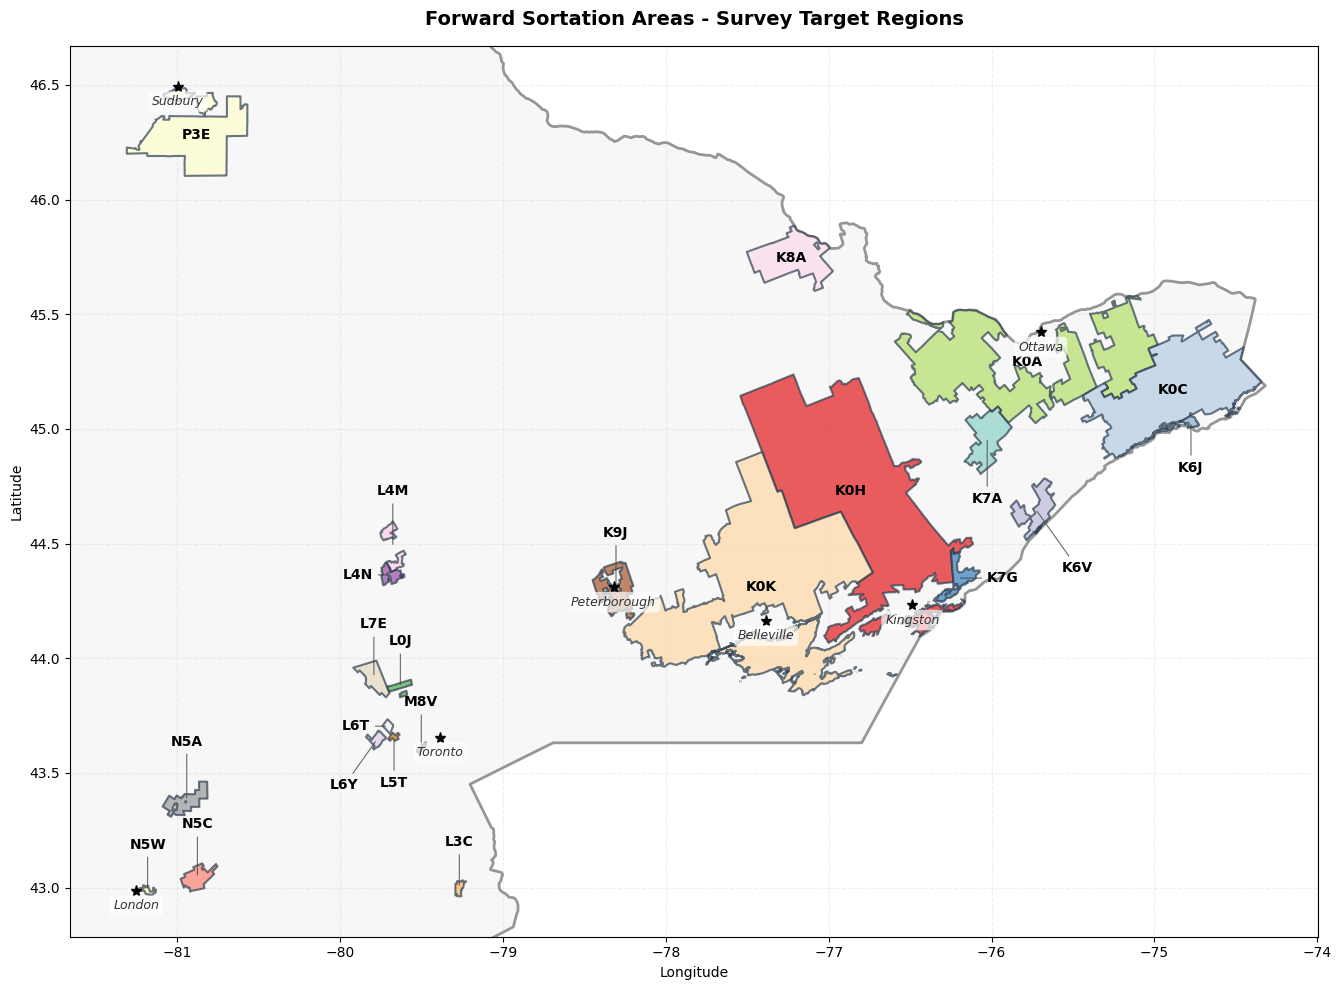

In [121]:
# Create FSA visualization using imported function
output_path = os.path.join(output_dir, 'fsa_visualization.png')
visualize_fsas(gdf_fsa_target, gdf_boundary_fsa, output_path=output_path, 
               label_directions=label_directions)